<a href="https://colab.research.google.com/github/ArchanaGajendra/Data-science-projects/blob/main/godigit_insuranceclaimpredicting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK: Predicting Insurance Claim Severity

Scenario:

An insurance company is aiming to improve its underwriting process by better predicting the severity of claims. Historical data include claim amounts, policyholder demographics (e.g., age, gender, location), vehicle details, and previous claim history over the past five years. The goal is to develop a predictive model that can estimate claim costs accurately to support pricing
decisions and risk management.

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import xgboost as xgb
from lightgbm import LGBMRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn import tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


# 1. Data Exploration & Preprocessing:

In [ ]:
# Load the dataset
df = pd.read_csv('/content/insurance_claims_dataset.csv')  #get dataset from my kaggle account - path:/kaggle/input/insurance-claim-severity/insurance_claims_dataset.csv

# Key Variables in the Dataset


1️⃣ Target Variable (What we are predicting)

ClaimAmount → The severity of the insurance claim (continuous variable).

2️⃣ Policyholder Demographics

Age → Age of the policyholder (numeric).

Gender → Male or Female (categorical).

Location → Urban, Suburban, or Rural (categorical).

3️⃣ Vehicle Details

VehicleAge → Age of the insured vehicle (numeric).

VehicleType → Sedan, SUV, Truck, etc. (categorical).

4️⃣ Policy & Claim History

PolicyCoverage → Type of coverage (e.g., Comprehensive, Third-party) (categorical).

PreviousClaims → Number of claims made in the past 5 years (numeric).

In [ ]:
# Lets explore the dataset
display(df.head())  #first 5 rows

# Records, features, column names.
print('No. of Records:',df.shape[0])
print('No. of Features:',df.shape[1])
print('Features:', df.columns)

#Shape of the dataset
print('Shape of the dataset:', df.shape)

#datatypes
print('Data types of the dataset:', df.dtypes)

#summary statistics
print('Summary statistics of the dataset:', df.describe())



,ClaimAmount,Age,Gender,Location,VehicleAge,VehicleType,PreviousClaims,PolicyCoverage
0,2346.34,71,Female,Urban,5,Sedan,1,Standard
1,15050.61,34,Male,Rural,14,Hatchback,0,Basic
2,6583.73,26,Female,Rural,14,Sedan,3,Basic
3,4564.71,50,Male,Suburban,0,Truck,0,Premium
4,848.12,70,Male,Urban,6,SUV,1,Premium


No. of Records: 500
No. of Features: 8
Features: Index(['ClaimAmount', 'Age', 'Gender', 'Location', 'VehicleAge', 'VehicleType',
       'PreviousClaims', 'PolicyCoverage'],
      dtype='object')
Shape of the dataset: (500, 8)
Data types of the dataset: ClaimAmount       float64
Age                 int64
Gender             object
Location           object
VehicleAge          int64
VehicleType        object
PreviousClaims      int64
PolicyCoverage     object
dtype: object
Summary statistics of the dataset:         ClaimAmount         Age  VehicleAge  PreviousClaims
count    500.000000  500.000000  500.000000      500.000000
mean    5021.545940   47.802000    6.964000        2.044000
std     4870.106219   18.172707    4.361737        1.403568
min       25.370000   18.000000    0.000000        0.000000
25%     1380.617500   31.750000    3.000000        1.000000
50%     3599.150000   48.000000    7.000000        2.000000
75%     7055.540000   64.000000   11.000000        3.000000
max    247

# Data Quality Issues & Preprocessing Methods

In [ ]:
# lets check for missing values
print('Missing values in the dataset:', df.isnull().sum())

#found none.
# But in case of missing values, then
# for column in df.columns:
#   if df[column].isnull().any():
#     if pd.api.types.is_numeric_dtype(df[column]):
#       df[column].fillna(df[column].mean(), inplace=True)  # Impute with mean for numerical columns
#     else:
#       df[column].fillna(df[column].mode()[0], inplace=True) # Impute with mode for categorical columns

Missing values in the dataset: ClaimAmount       0
Age               0
Gender            0
Location          0
VehicleAge        0
VehicleType       0
PreviousClaims    0
PolicyCoverage    0
dtype: int64


In [ ]:
#lets check and remove outliners
def remove_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

numerical_columns = ["ClaimAmount", "Age", "VehicleAge", "PreviousClaims"]
for col in numerical_columns:
    remove_outliers(col)
#identified outliers in ClaimAmount by replacing them with the upper bound calculated using the IQR method.

In [ ]:
# Handle outliers in ClaimAmount by replacing them with the upper bound
Q1 = df['ClaimAmount'].quantile(0.25)
Q3 = df['ClaimAmount'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

df['ClaimAmount'] = df['ClaimAmount'].apply(lambda x: upper_bound if x > upper_bound else x)

In [ ]:
# Identify categorical and numerical features
categorical_features = ['Gender', 'Location', 'VehicleType', 'PolicyCoverage']
numerical_features = ['Age', 'VehicleAge', 'PreviousClaims', 'ClaimAmount']

# One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=categorical_features)


# The new DataFrame for model training is df_encoded
display(df_encoded.head())

,ClaimAmount,Age,VehicleAge,PreviousClaims,Gender_Female,Gender_Male,Location_Rural,Location_Suburban,Location_Urban,VehicleType_Hatchback,VehicleType_SUV,VehicleType_Sedan,VehicleType_Truck,PolicyCoverage_Basic,PolicyCoverage_Premium,PolicyCoverage_Standard
0,2346.34,71.0,5.0,1.0,True,False,False,False,True,False,False,True,False,False,False,True
1,15050.61,34.0,14.0,0.0,False,True,True,False,False,True,False,False,False,True,False,False
2,6583.73,26.0,14.0,3.0,True,False,True,False,False,False,False,True,False,True,False,False
3,4564.71,50.0,0.0,0.0,False,True,False,True,False,False,False,False,True,False,True,False
4,848.12,70.0,6.0,1.0,False,True,False,False,True,False,True,False,False,False,True,False


In [ ]:
# I have added log transformation for ClaimAmount to reduce skewness and stabilize variance.
#Log Transformation for Skewed Data
df["ClaimAmount"] = np.log1p(df["ClaimAmount"])  # log(ClaimAmount + 1) to handle zero values

# after preprocessing
print(df_encoded.head())

   ClaimAmount   Age  VehicleAge  PreviousClaims  Gender_Female  Gender_Male  \
0      2346.34  71.0         5.0             1.0           True        False   
1     15050.61  34.0        14.0             0.0          False         True   
2      6583.73  26.0        14.0             3.0           True        False   
3      4564.71  50.0         0.0             0.0          False         True   
4       848.12  70.0         6.0             1.0          False         True   

   Location_Rural  Location_Suburban  Location_Urban  VehicleType_Hatchback  \
0           False              False            True                  False   
1            True              False           False                   True   
2            True              False           False                  False   
3           False               True           False                  False   
4           False              False            True                  False   

   VehicleType_SUV  VehicleType_Sedan  Vehic

# 2. Exploratory Data Analysis (EDA):

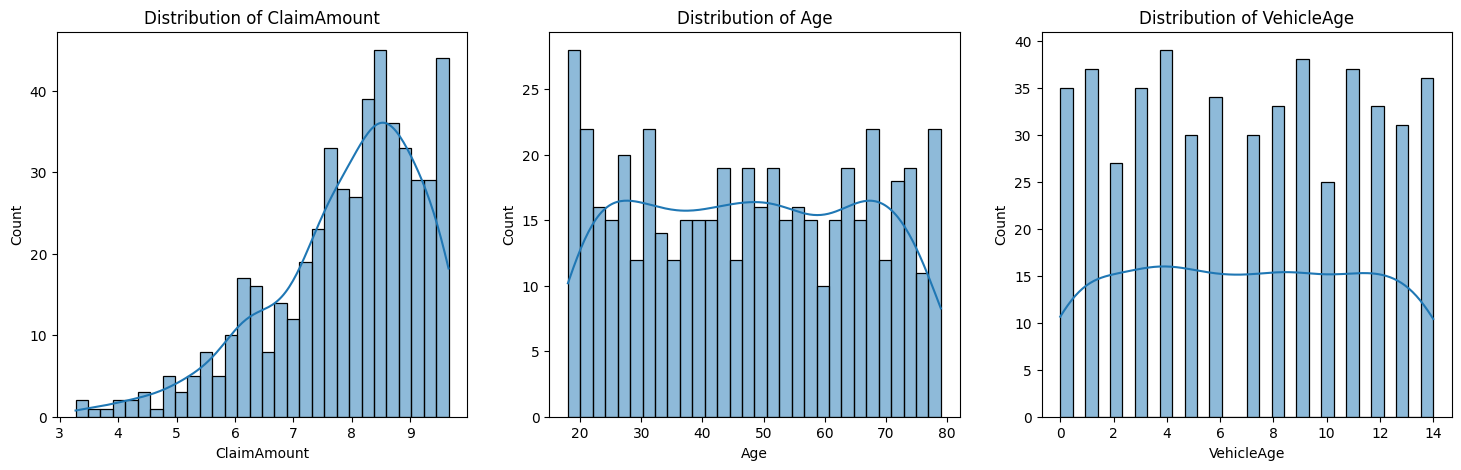

In [ ]:
# Histogram for ClaimAmount, Age, and VehicleAge
plt.figure(figsize=(18, 5))
for i, col in enumerate(["ClaimAmount", "Age", "VehicleAge"]):
    plt.subplot(1, 3, i + 1)
    sb.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
plt.show()

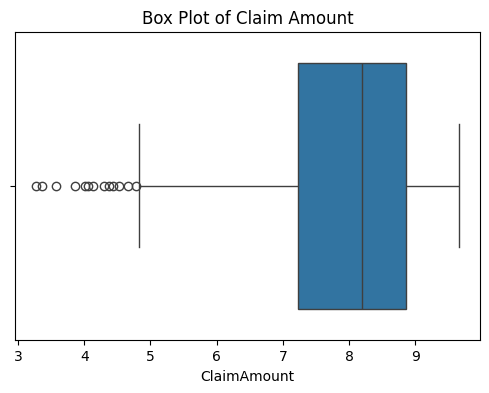

In [ ]:
#Box Plot for ClaimAmount (to detect outliers)
plt.figure(figsize=(6, 4))
sb.boxplot(x=df["ClaimAmount"])
plt.title("Box Plot of Claim Amount")
plt.show()

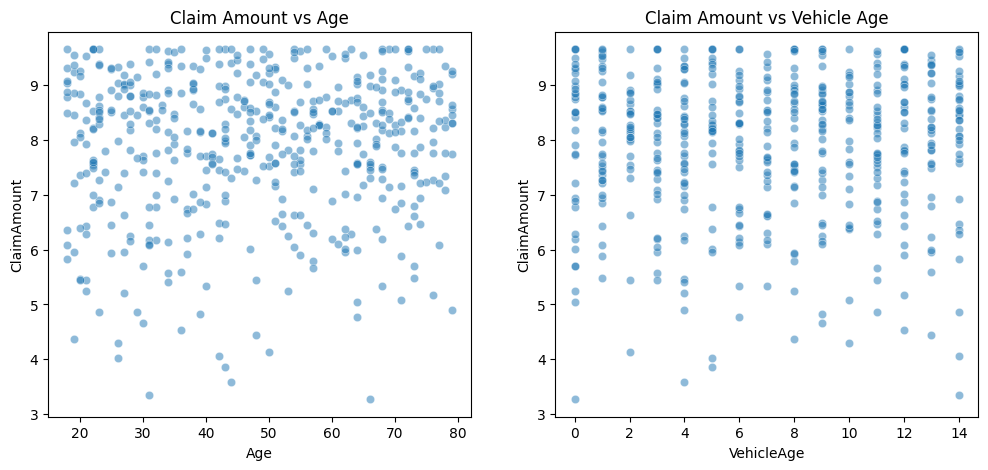

In [ ]:
# Scatter Plots: ClaimAmount vs Age & VehicleAge
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sb.scatterplot(x=df["Age"], y=df["ClaimAmount"], alpha=0.5)
plt.title("Claim Amount vs Age")
plt.subplot(1, 2, 2)
sb.scatterplot(x=df["VehicleAge"], y=df["ClaimAmount"], alpha=0.5)
plt.title("Claim Amount vs Vehicle Age")
plt.show()

In [ ]:
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix["ClaimAmount"].sort_values(ascending=False))
### Values range from -1 to 1:
#+1 → Strong positive correlation (as one increases, the other increases).
#-1 → Strong negative correlation (as one increases, the other decreases).
# 0 → No correlation.
# We use a correlation heatmap to visualize this.

ClaimAmount       1.000000
Age               0.054075
VehicleAge        0.004119
PreviousClaims    0.003154
Name: ClaimAmount, dtype: float64


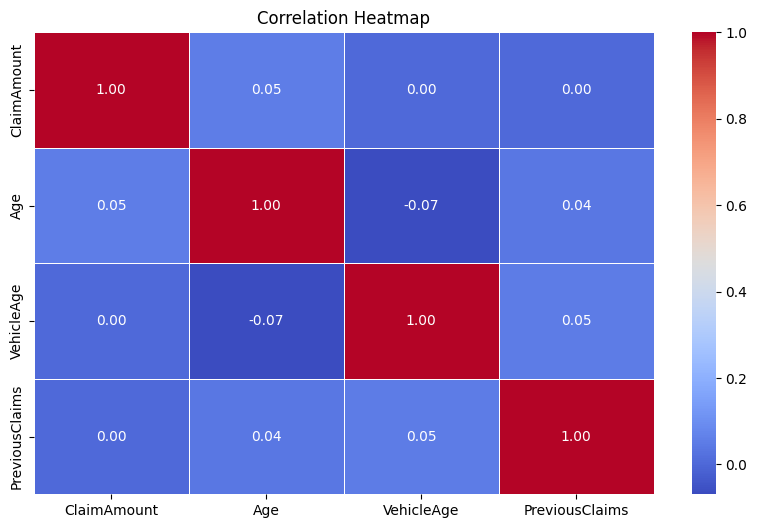

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sb.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# 3. Model Building:

In [ ]:
# Split data into training (80%) and testing (20%)
# Defining features (X) and target variable (y)
X = df_encoded.drop(columns=["ClaimAmount"])
y = df_encoded["ClaimAmount"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#MODEL PROPOSING
#Better Model for Predicting Insurance Claim Severity
#LightGBM (Light Gradient Boosting Machine) is faster and more efficient than traditional models like Random Forest and XGBoost.
# Faster than XGBoost and works well for small datasets.
# Handles categorical data & missing values automatically.
# Less prone to overfitting compared to Random Forest.


# Since Linear Regression, Random Forest, and XGBoost are giving a negative R2 score, lightgbm regressor better models that can handle complex patterns and improve accuracy.

In [ ]:
from lightgbm import LGBMRegressor
lgb_model = LGBMRegressor(n_estimators=5, learning_rate=0.05, max_depth=7)
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000060 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 104
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 15
[LightGBM] [Info] Start training from score 4957.734680
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMRegressor(learning_rate=0.05, max_depth=7, n_estimators=5)

In [ ]:
# Make predictions on test set
y_pred = lgb_model.predict(X_test)

In [ ]:
# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Model Performance:
MAE: 3280.19
RMSE: 4138.73
R² Score: 0.01


In [ ]:
# Predict on New Unseen Data (Example:predicting the claim amount of female person with truck, vehicle age 5yrs and had 2 claims before)
new_data = pd.DataFrame({
    "Age": [25],
    " VehicleAge": [10.0],
    "PreviousClaims": [1.0],
    "Gender_Female": [0],
    "Gender_Male": [1],
    "Location_Rural": [0],
    "Location_Suburban": [1],
    "Location_Urban": [0],                                                      #try changing the values and see the predicted claim amount
    "VehicleType_Hatchback": [0],
    "VehicleType_SUV":  [0],
    "VehicleType_Sedan":  [0],
    "VehicleType_Truck": [1],
    "PolicyCoverage_Basic":  [0],
    "PolicyCoverage_Premium":  [0],
    "PolicyCoverage_Standard": [1]})

In [ ]:
# Predict claim amount for new data
predicted_claim = lgb_model.predict(new_data)
print(f"\nPredicted Claim Amount: {predicted_claim[0]:.2f}")


Predicted Claim Amount: 4682.79
